# NB1 - Analyse exploratoire du dataset invoices

## English Summary

### Purpose
Exploratory Data Analysis (EDA) of the invoice dataset used to train the Promy OCR model.

### Role in the project
This notebook characterizes the dataset before any modeling step. Its findings inform the preprocessing choices in NB2 and the training configuration in NB3.

### Inputs
- Kaggle dataset "High Quality Invoice Images for OCR"
  - batch_1: 1,413 annotated invoices with CSV ground truth (invoice_number, invoice_date, total, tax, items)
  - batch_2: 300 unannotated invoices

### Main steps
- Dataset volume inventory: image counts, CSV structure, annotation fill rates
- Visual characteristics: resolution, brightness, and contrast distribution per batch
- Image gallery: sanity check on raw invoice appearance
- Image/CSV consistency check
- Lexical analysis of the "OCRed Text" field
- Bias and limitation documentation
- Text line distribution per image: segment count and width/height ratio
- Layout and template homogeneity (qualitative)
- JSON field format analysis: invoice_date, invoice_number, total, tax

### Outputs
- Documented understanding of dataset structure, quality, and biases
- Design constraints for NB2 (which preprocessing steps are needed) and NB3 (split strategy, input granularity)

### Key methodological choices
- Analysis is centered on batch_1. batch_2 is used only for qualitative generalization testing.
- The high width/height ratio of text line crops (~32px height, wide lines) requires line-by-line processing rather than full-page OCR. This finding drives the crop-based approach used in NB3.
- The 75/25 anti-leakage split by invoice in NB3 is motivated here: splitting by crop would contaminate the validation set with templates already seen at training time.

### Known limitations
- batch_1 is a single-source English corpus. Generalization to other invoice styles or French documents is not supervised.
- Some annotation fields (due_date, seller_name, client_address) have low fill rates and are not reliable as training targets.
- "OCRed Text" provides document-level text, not line-level bounding boxes. This constrains the pseudo-labelling approach used in NB3.

### Where to look
- Section 7 for documented dataset biases and their downstream impact
- Section 8 for the rationale behind line-by-line processing
- Section 11 for the summary and transition to NB2 and NB3

## Ce notebook documente l'état des lieux du dataset avant tout pipeline


L'objectif est de comprendre la distribution réelle des données, d'en caractériser la qualité, les biais et les limites afin d'alimenter NB2 (preprocessing) et NB3 (fine-tuning du modèle retenu).

**Contexte projet** : le pipeline cible l'extraction automatique de champs clés depuis des factures scannées (numéro, date, montants). NB1 caractérise la donnée disponible ; NB3 entraîne le modèle de reconnaissance de caractères sur cette base.


## 0. Imports et chemins

### Imports

In [ ]:
import csv      # csv / json : lecture des annotations Kaggle (CSV + colonne 'Json Data')
import json
import re
import sys
import warnings
from collections import Counter
from pathlib import Path

import cv2      # cv2 / PIL : lecture et analyse des images de factures
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110
from IPython.display import HTML, Markdown, display

print("Dépendances chargées.")

Dépendances chargées.


**Recherche de la racine du projet**

Le notebook peut être lancé depuis n'importe quel répertoire.

On remonte l'arborescence jusqu'à trouver 'notebooks/' ET 'Promy_raw/' pour s'en assurer.

**Chemins principaux**

`BATCH1_DIR = batch_1/batch_1`  le dataset Kaggle a une double imbrication.

`normalize_batch_dir()` gère ce cas automatiquement.

In [2]:
def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "Promy_raw").exists():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory")


PROJECT_ROOT = find_project_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
DATASET_ROOT = PROJECT_ROOT / "Promy_raw" / "datasets" / "High-Quality Invoice Images for OCR"
MODELS_DIR = PROJECT_ROOT / "models"
BATCH1_DIR = DATASET_ROOT / "batch_1" / "batch_1"
BATCH2_DIR = DATASET_ROOT / "batch_2" / "batch_2"

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from preprocessing import extract_text_line_crops

print(f"Racine projet : {PROJECT_ROOT.name} | batch_1 accessible : {BATCH1_DIR.exists()}")

Racine projet : Work | batch_1 accessible : True


### Fonctions utilitaires partagées

`normalize_batch_dir` : corrige la double imbrication Kaggle

`list_image_paths`    : rglob sur jpg/jpeg/png, résultats triés

`load_csv_rows`       : charge les CSV et garde le chemin source

`find_invoice_image`  : retrouve l'image correspondant à une ligne CSV

`parse_json_data`     : transforme `Json Data` en dictionnaire exploitable


In [3]:
def relative_path(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()


def normalize_batch_dir(batch_dir):
    batch_dir = Path(batch_dir)
    nested = batch_dir / batch_dir.name
    return nested if nested.exists() else batch_dir


def batch_leaf_dirs(batch_dir):
    batch_dir = normalize_batch_dir(batch_dir)
    return sorted([p for p in batch_dir.iterdir() if p.is_dir()])


def list_image_paths(batch_dir):
    batch_dir = normalize_batch_dir(batch_dir)
    return sorted([p for p in batch_dir.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])


def find_invoice_image(filename, batch_dir=BATCH1_DIR):
    batch_dir = normalize_batch_dir(batch_dir)
    for candidate in batch_dir.rglob(filename):
        if candidate.is_file():
            return candidate
    return None


def load_csv_rows(batch_dir=BATCH1_DIR):
    batch_dir = normalize_batch_dir(batch_dir)
    rows = []
    for csv_path in sorted(batch_dir.rglob("*.csv")):
        with csv_path.open(encoding="utf-8", newline="") as handle:
            reader = csv.DictReader(handle)
            for row in reader:
                item = dict(row)
                item["source_csv"] = csv_path.name
                rows.append(item)
    return rows


def safe_json_loads(text):
    try:
        return json.loads(text)
    except Exception:
        return {}

print("Fonctions utilitaires chargées.")

Fonctions utilitaires chargées.


### Chargement du dataset batch_1

In [4]:
print("Initialisation du projet terminée")
print(f"- racine dataset    : {DATASET_ROOT.name}")
print(f"- sous-dossiers batch_1 : {[p.name for p in batch_leaf_dirs(BATCH1_DIR)]}")
print(f"- sous-dossiers batch_2 : {[p.name for p in batch_leaf_dirs(BATCH2_DIR)]}")

rows = load_csv_rows(BATCH1_DIR)
df = pd.DataFrame(rows)
print(f"Lignes batch_1 chargées : {len(df)}")
print(f"Fichiers CSV : {[p.name for p in sorted(BATCH1_DIR.glob('*.csv'))]}")

Initialisation du projet terminée
- racine dataset    : High-Quality Invoice Images for OCR
- sous-dossiers batch_1 : ['batch1_1', 'batch1_2', 'batch1_3']
- sous-dossiers batch_2 : ['batch2_1', 'batch2_2', 'batch2_3']
Lignes batch_1 chargées : 1414
Fichiers CSV : ['batch1_1.csv', 'batch1_2.csv', 'batch1_3.csv']


## 1. Dataset Volume / Volumétrie

Inventaire des deux batches : nombre de sous-dossiers, de CSV et d'images.

Batch_1 = dataset annoté (CSV + Json Data) => base d'entraînement et d'évaluation.

Batch_2 = images sans annotation => utilisé uniquement pour tester la généralisation.

Cette cellule révèle aussi si le dataset est équilibré entre les batches.

In [5]:
batch_rows = []
for batch_dir in sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir() and p.name.startswith("batch_")]):
    batch_rows.append(
        {
            "batch": batch_dir.name,
            "n_subdirs": len(batch_leaf_dirs(batch_dir)),
            "n_csv": len(list(normalize_batch_dir(batch_dir).rglob("*.csv"))),
            "n_images": len(list_image_paths(batch_dir)),
        }
    )

df_batches = pd.DataFrame(batch_rows).sort_values("batch")
print(df_batches.to_string(index=False))


  batch  n_subdirs  n_csv  n_images
batch_1          3      3      1489
batch_2          3      0      1491
batch_3          5      0      2221


## 2. Analyse des CSV - champs, taux de remplissage, ground truth

On déplie la colonne 'Json Data' (JSON stringifié) en colonnes exploitables.

Structure JSON du dataset Kaggle :

```
  { 'invoice': {invoice_number, invoice_date, due_date, seller_name, client_address},
    'subtotal': {total, tax},
    'items': [ {description, quantity, unit_price, total}, ... ] }
```

`fill_rates` : taux de remplissage de chaque champ => indique quels champs sont assez couverts pour servir de ground truth fiable en apprentissage.

Un taux faible = ground truth trop partielle pour évaluer ce champ.

In [6]:
parsed_rows = []
for row in df.to_dict("records"):
    obj = safe_json_loads(row["Json Data"])
    invoice = obj.get("invoice", {})
    subtotal = obj.get("subtotal", {})
    items = obj.get("items", [])
    parsed_rows.append(
        {
            "filename": row["File Name"],
            "source_csv": row["source_csv"],
            "ocr_text": str(row.get("OCRed Text", "") or ""),
            "json_ok": bool(obj),
            "n_items": len(items) if isinstance(items, list) else 0,
            "ocr_len": len(str(row.get("OCRed Text", "") or "")),
            "inv_invoice_number": str(invoice.get("invoice_number", "") or ""),
            "inv_invoice_date": str(invoice.get("invoice_date", "") or ""),
            "inv_due_date": str(invoice.get("due_date", "") or ""),
            "inv_seller_name": str(invoice.get("seller_name", "") or ""),
            "inv_client_address": str(invoice.get("client_address", "") or ""),
            "sub_total": str(subtotal.get("total", "") or ""),
            "sub_tax": str(subtotal.get("tax", "") or ""),
        }
    )

df_parsed = pd.DataFrame(parsed_rows)
fill_cols = [
    "inv_invoice_number",
    "inv_invoice_date",
    "inv_due_date",
    "inv_seller_name",
    "inv_client_address",
    "sub_total",
    "sub_tax",
]
fill_rates = {
    col: (df_parsed[col].astype(str).str.strip() != "").mean() * 100
    for col in fill_cols
}

print("Taux de remplissage des champs : batch_1")
for name, rate in fill_rates.items():
    print(f"- {name:20s}: {rate:6.1f}%")

print("\nRésumé ground truth")
print(f"- lignes JSON parsées     : {df_parsed['json_ok'].sum()} / {len(df_parsed)}")
print(f"- items par facture       : moyenne={df_parsed['n_items'].mean():.2f}, médiane={df_parsed['n_items'].median():.0f}")
print(f"- longueur OCRed Text     : moyenne={df_parsed['ocr_len'].mean():.0f}, médiane={df_parsed['ocr_len'].median():.0f}")

Taux de remplissage des champs : batch_1
- inv_invoice_number  :  100.0%
- inv_invoice_date    :  100.0%
- inv_due_date        :    0.0%
- inv_seller_name     :  100.0%
- inv_client_address  :  100.0%
- sub_total           :  100.0%
- sub_tax             :  100.0%

Résumé ground truth
- lignes JSON parsées     : 1414 / 1414
- items par facture       : moyenne=3.96, médiane=4
- longueur OCRed Text     : moyenne=829, médiane=811


## 3. Visual Characteristics / Caractéristiques visuelles des images

Analyse des caractéristiques visuelles sur un échantillon aléatoire (max 200 images/batch).

`rng = np.random.default_rng(42)` = reproductibilité entre les runs.

Pour chaque image :

*width / height*    : variabilité de résolution => input du resize_to_width

*brightness (mean)* : images trop sombres vs trop claires

*contrast (std)*    : plage dynamique disponible avant CLAHE

Les 3 graphes (résolution, luminosité, contraste) motivent le choix du preprocessing.

Images analysées pour le résumé visuel : 600
           n  width_mean  height_mean  brightness_mean  contrast_mean
batch                                                                
batch_1  200     1654.00      2339.00           246.83          30.92
batch_2  200     2428.17      3356.25           247.50          33.34
batch_3  200     2704.50      3822.73           246.97          31.15


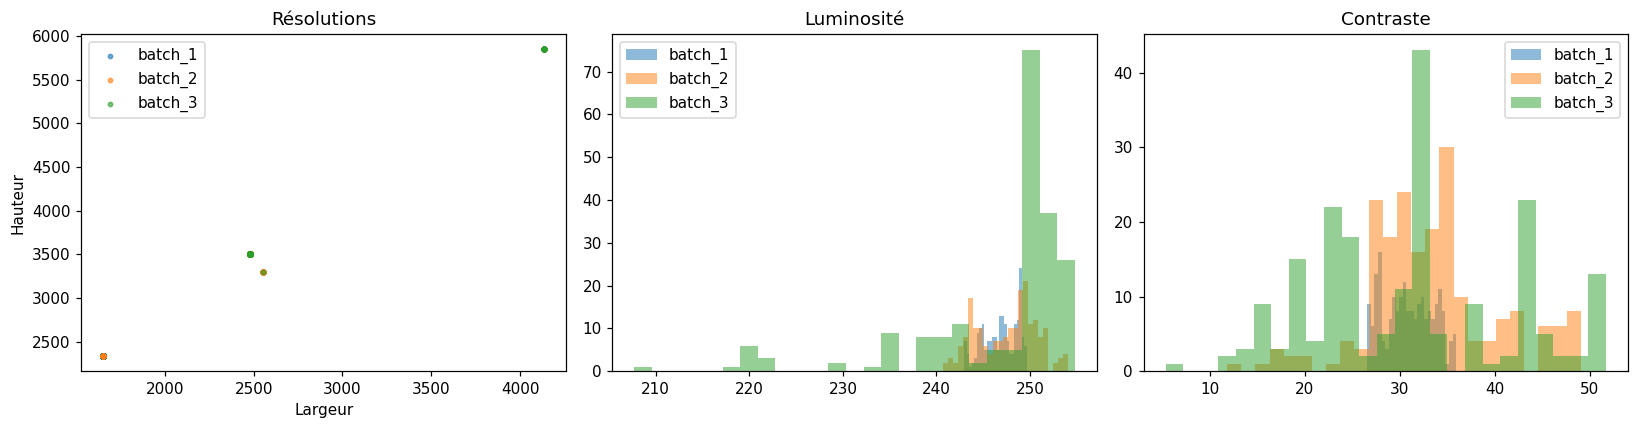

In [7]:
rng = np.random.default_rng(42)
visual_rows = []

for batch_dir in sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir() and p.name.startswith("batch_")]):
    images = list_image_paths(batch_dir)
    if not images:
        continue
    sample = images if len(images) <= 200 else list(rng.choice(images, size=200, replace=False))
    for img_path in sample:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = gray.shape
        visual_rows.append(
            {
                "batch": batch_dir.name,
                "width": w,
                "height": h,
                "brightness": float(gray.mean()),
                "contrast": float(gray.std()),
            }
        )

df_visual = pd.DataFrame(
    visual_rows,
    columns=["batch", "width", "height", "brightness", "contrast"],
)
print(f"Images analysées pour le résumé visuel : {len(df_visual)}")

if df_visual.empty:
    print("Aucun fichier image trouvé pour cette section. Vérifier DATASET_ROOT et les dossiers de batch.")
else:
    summary = df_visual.groupby("batch").agg(
        n=("width", "count"),
        width_mean=("width", "mean"),
        height_mean=("height", "mean"),
        brightness_mean=("brightness", "mean"),
        contrast_mean=("contrast", "mean"),
    )
    print(summary.round(2).to_string())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for batch_name, group in df_visual.groupby("batch"):
        axes[0].scatter(group["width"], group["height"], s=8, alpha=0.6, label=batch_name)
        axes[1].hist(group["brightness"], bins=25, alpha=0.5, label=batch_name)
        axes[2].hist(group["contrast"], bins=25, alpha=0.5, label=batch_name)
    axes[0].set_title("Résolutions")
    axes[0].set_xlabel("Largeur")
    axes[0].set_ylabel("Hauteur")
    axes[1].set_title("Luminosité")
    axes[2].set_title("Contraste")
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()


## 4. Galerie d'échantillons

Galerie visuelle : 2 images par batch, affichées pleine largeur.

But : sanity-check rapide. Vérifier que les images sont lisibles, qu'elles ressemblent bien à des factures et repérer des problèmes évidents. (images corrompues, photos floues, mauvaise orientation).

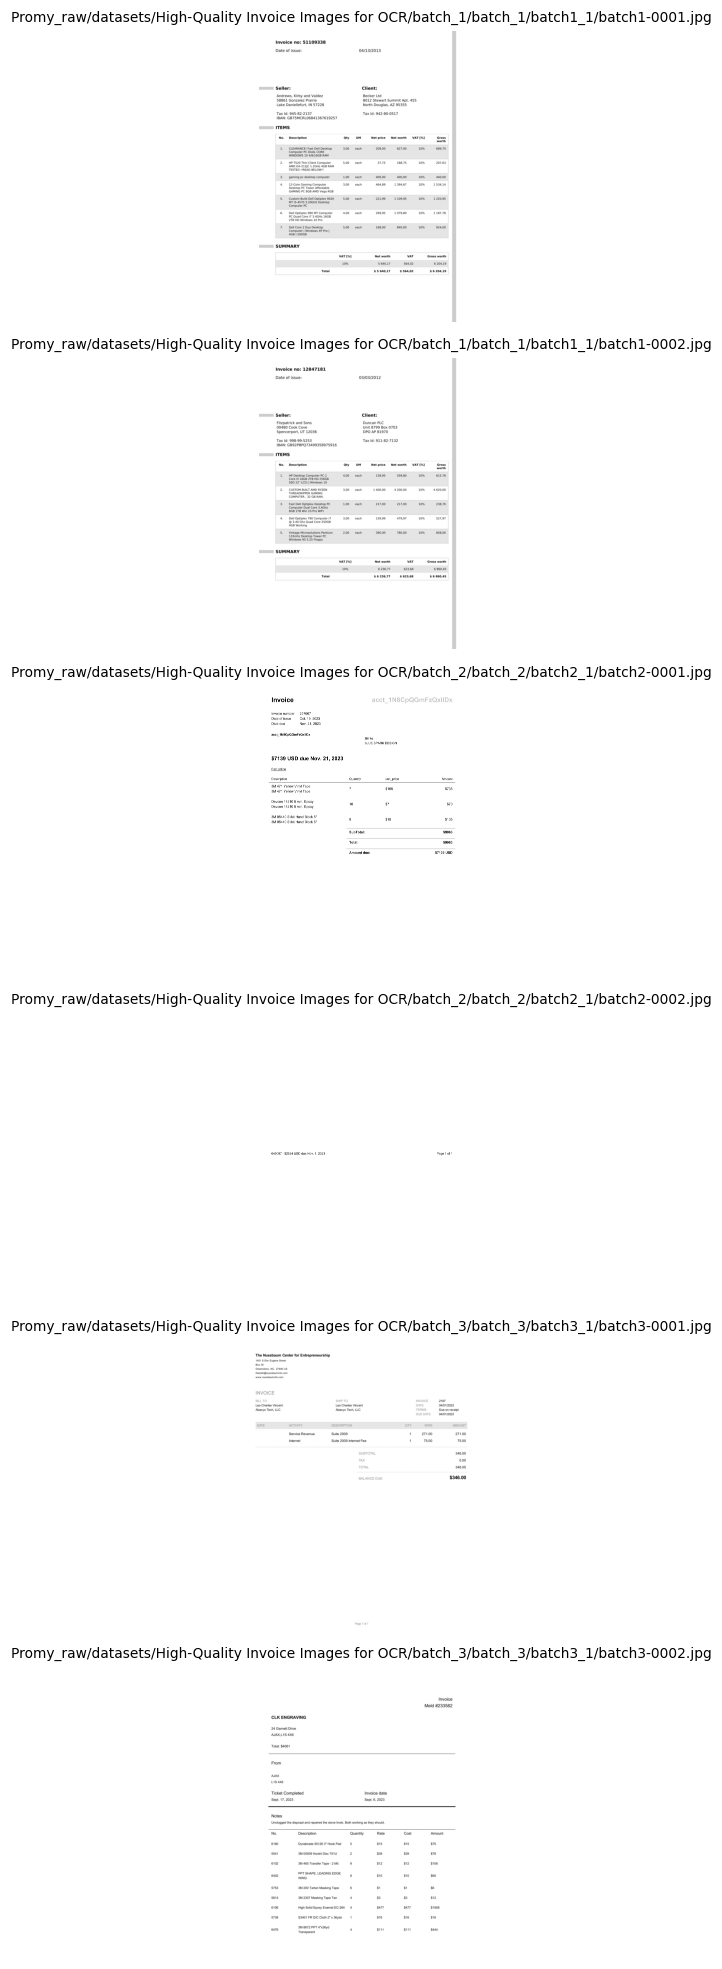

In [8]:
gallery_paths = []
for batch_dir in sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir() and p.name.startswith("batch_")]):
    images = list_image_paths(batch_dir)
    if images:
        gallery_paths.extend(images[:2])

fig, axes = plt.subplots(len(gallery_paths), 1, figsize=(12, 3 * len(gallery_paths)))
if len(gallery_paths) == 1:
    axes = [axes]
for ax, img_path in zip(axes, gallery_paths):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(relative_path(img_path), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Cohérence images / CSV

On tente de retrouver sur disque chaque image référencée dans le CSV.

`find_invoice_image()` fait un *rglob* par nom de fichier dans le batch.

Si des images manquent = problème de téléchargement ou de structure de dossier.

Toutes les lignes avec `image_path=None` seront ignorées dans les sections suivantes.

In [9]:
df_parsed["image_path"] = df_parsed["filename"].apply(find_invoice_image)
missing_images = df_parsed["image_path"].isna().sum()
print(f"Images manquantes référencées dans le CSV : {missing_images}")
if missing_images:
    print(df_parsed.loc[df_parsed["image_path"].isna(), ["filename", "source_csv"]].head().to_string(index=False))
else:
    print("Toutes les lignes du batch_1 correspondent à un fichier image")

Images manquantes référencées dans le CSV : 0
Toutes les lignes du batch_1 correspondent à un fichier image


## 6. Analyse lexicale de OCRed Text


Cette section analyse le lexique de `OCRed Text` et la variabilité des champs annotés pour caractériser la structure de la donnée disponible pour l'entraînement.

,token,occurrences,part_du_top_pct
0,10%,7016,13.8
1,worth,5656,11.1
2,each,5602,11.0
3,Net,4242,8.3
4,VAT,4242,8.3
5,$,4193,8.2
6,Gross,2831,5.6
7,Tax,2828,5.6
8,Id:,2828,5.6
9,[%],2828,5.6


,signal,occurrences,part_vs_chiffres_pct
0,chiffres 0-9,269518,100.0
1,$,4218,1.6
2,%,9876,3.7
3,",",34890,12.9
4,.,2687,1.0
5,/,3204,1.2
6,:,10568,3.9
7,#,27,0.0
8,-,7490,2.8


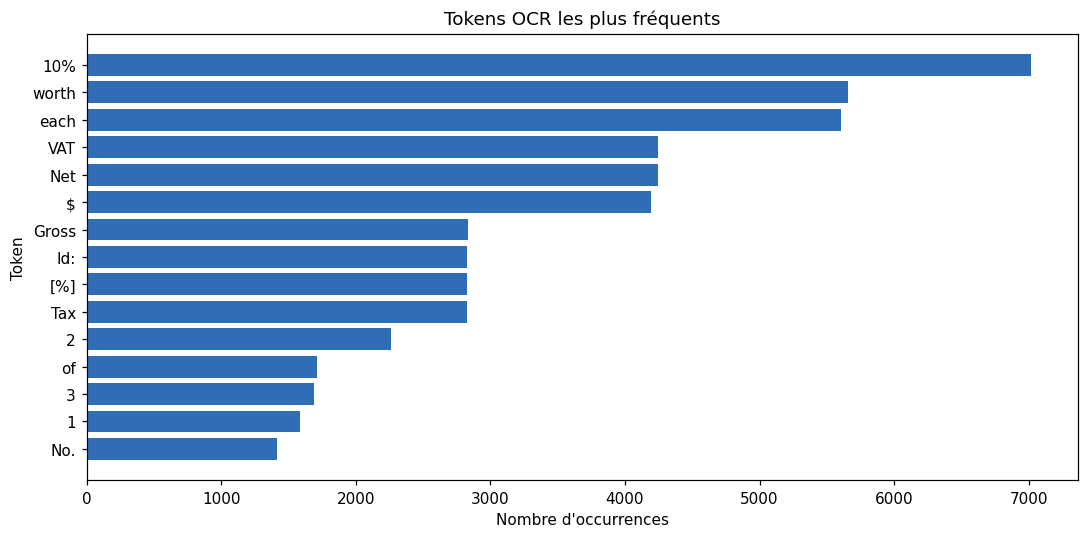

In [10]:
TOP_TOKEN_COUNT = 15
KEY_CHARACTERS = ["$", "%", ",", ".", "/", ":", "#", "-"]

ocr_token_counter = Counter()
ocr_character_counter = Counter()
for text in df_parsed["ocr_text"].astype(str):
    tokens = [token for token in re.split(r"\s+", text) if token]
    ocr_token_counter.update(tokens)
    ocr_character_counter.update(text)

df_top_tokens = pd.DataFrame(
    ocr_token_counter.most_common(TOP_TOKEN_COUNT),
    columns=["token", "occurrences"],
)
df_top_tokens["part_du_top_pct"] = (
    100 * df_top_tokens["occurrences"] / df_top_tokens["occurrences"].sum()
).round(1)

digit_occurrences = sum(ocr_character_counter.get(str(digit), 0) for digit in range(10))
character_rows = [{"signal": "chiffres 0-9", "occurrences": digit_occurrences}]
for character in KEY_CHARACTERS:
    character_rows.append(
        {
            "signal": character,
            "occurrences": ocr_character_counter.get(character, 0),
        }
    )

df_character_signals = pd.DataFrame(character_rows)
df_character_signals["part_vs_chiffres_pct"] = np.where(
    digit_occurrences > 0,
    (100 * df_character_signals["occurrences"] / digit_occurrences).round(1),
    np.nan,
)

display(df_top_tokens)
display(df_character_signals)

fig, ax = plt.subplots(figsize=(10, 5))
plot_tokens = df_top_tokens.sort_values("occurrences")
ax.barh(plot_tokens["token"], plot_tokens["occurrences"], color="#2F6DB5")
ax.set_title("Tokens OCR les plus fréquents")
ax.set_xlabel("Nombre d'occurrences")
ax.set_ylabel("Token")
plt.tight_layout()
plt.show()


### Interprétation

Le lexique OCR fait bien remonter les mots-clés attendus d'une facture ainsi que les signes utiles à l'extraction de champs.
La présence forte des chiffres, séparateurs et ponctuations monétaires confirme que le texte OCR porte l'information nécessaire pour viser `invoice_number`, `invoice_date`, `total` et `tax`.
Cette vue reste cependant une analyse globale de `OCRed Text` : elle décrit le vocabulaire OCR dominant, pas encore la variabilité du ground truth JSON champ par champ.


## 7. Biases and Limitations / Biais et limites identifiés

Cette section reformule explicitement les biais identifiés.
L'objectif n'est pas seulement de dire que le dataset a des défauts mais de préciser leur impact sur NB3 et sur la généralisation.


In [11]:
def batch_image_count(batch_name):
    batch_match = df_batches.loc[df_batches["batch"] == batch_name, "n_images"]
    if batch_match.empty:
        return 0
    return int(batch_match.iloc[0])


seller_name_values = df_parsed["inv_seller_name"].astype(str).str.strip()
seller_name_values = seller_name_values[seller_name_values != ""]
client_address_values = df_parsed["inv_client_address"].astype(str).str.strip()
client_address_values = client_address_values[client_address_values != ""]

seller_name_unique_ratio = 100 * seller_name_values.nunique() / max(len(seller_name_values), 1)
client_address_unique_ratio = 100 * client_address_values.nunique() / max(len(client_address_values), 1)
client_address_average_length = client_address_values.str.len().mean()

batch_2_images = batch_image_count("batch_2")
batch_3_images = batch_image_count("batch_3")

df_bias_summary = pd.DataFrame(
    [
        {
            "biais_limite": "Supervision concentrée sur batch_1",
            "signal_mesure": f"{len(df_parsed)} factures annotées en batch_1 ; batch_2={batch_2_images} images sans même niveau de supervision",
            "impact_sur_nb3": "NB3 apprend surtout un template annoté ; la généralisation hors batch_1 devra être documentée et non supposée.",
        },
        {
            "biais_limite": "due_date absent",
            "signal_mesure": f"Taux de remplissage = {fill_rates['inv_due_date']:.1f}%",
            "impact_sur_nb3": "Champ absent de batch_1 : aucune valeur de référence disponible pour l'entraînement.",
        },
        {
            "biais_limite": "OCRed Text au niveau document",
            "signal_mesure": f"Longueur médiane OCRed Text = {df_parsed['ocr_len'].median():.0f} caractères",
            "impact_sur_nb3": "Le texte CSV ne s'aligne pas ligne par ligne avec les crops ; les pénalites CER document doivent être interprétées avec prudence.",
        },
        {
            "biais_limite": "seller_name très variable",
            "signal_mesure": f"{seller_name_values.nunique()} valeurs uniques / {len(seller_name_values)} factures ({seller_name_unique_ratio:.1f}% d'unicité)",
            "impact_sur_nb3": "Champ nominal très variable ; peu structuré pour un suivi métrique direct.",
        },
        {
            "biais_limite": "client_address très variable",
            "signal_mesure": f"{client_address_values.nunique()} valeurs uniques ; longueur moyenne {client_address_average_length:.0f} caractères ; {client_address_unique_ratio:.1f}% d'unicité",
            "impact_sur_nb3": "Structure ouverte et variable ; difficile à traiter sans post-traitement dédié.",
        },
        {
            "biais_limite": "Risque de généralisation vers batch_2 et batch_3",
            "signal_mesure": f"batch_2={batch_2_images} images, batch_3={batch_3_images} images",
            "impact_sur_nb3": "Les gains observés sur batch_1 ne pourront pas être extrapolés automatiquement aux autres batches.",
        },
    ]
)

bias_display = df_bias_summary.copy()
bias_css = """
<style>
.bias-table table {width: 100%; border-collapse: collapse;}
.bias-table th, .bias-table td {padding: 8px 10px; text-align: left; vertical-align: top; border: 1px solid #d0d7de;}
.bias-table th {background: #f6f8fa;}
.bias-table td {white-space: normal;}
</style>
"""
bias_html = bias_display.to_html(index=False, escape=False)
display(HTML(bias_css + f'<div class="bias-table">{bias_html}</div>'))


biais_limite,signal_mesure,impact_sur_nb3
Supervision concentrée sur batch_1,1414 factures annotées en batch_1 ; batch_2=1491 images sans même niveau de supervision,NB3 apprend surtout un template annoté ; la généralisation hors batch_1 devra être documentée et non supposée.
due_date absent,Taux de remplissage = 0.0%,Champ absent de batch_1 : aucune valeur de référence disponible pour l'entraînement.
OCRed Text au niveau document,Longueur médiane OCRed Text = 811 caractères,Le texte CSV ne s'aligne pas ligne par ligne avec les crops ; les pénalites CER document doivent être interprétées avec prudence.
seller_name très variable,1361 valeurs uniques / 1414 factures (96.3% d'unicité),Champ nominal très variable ; peu structuré pour un suivi métrique direct.
client_address très variable,1413 valeurs uniques ; longueur moyenne 44 caractères ; 99.9% d'unicité,Structure ouverte et variable ; difficile à traiter sans post-traitement dédié.
Risque de généralisation vers batch_2 et batch_3,"batch_2=1491 images, batch_3=2221 images",Les gains observés sur batch_1 ne pourront pas être extrapolés automatiquement aux autres batches.


### Lecture des biais

L'analyse supervisée est centrée sur `batch_1`, ce qui borne d'emblée la portée de ce que `NB3` pourra démontrer.
L'absence de `due_date`, le caractère document-level de `OCRed Text` et la forte variabilité de `seller_name` et `client_address` limitent le nombre de champs structurellement stables dans le dataset.
Les résultats obtenus sur `batch_2` et sur les tests hors corpus devront donc être présentés comme un test de généralisation, pas comme un prolongement automatique du même niveau de preuve.


## 8. Text Line Distribution / Distribution des lignes par image

On échantillonne 120 factures pour mesurer la charge réelle de segmentation avant l'étape de reconnaissance.

`extract_text_line_crops()` (depuis `preprocessing.py`) applique la projection horizontale.

Les deux métriques centrales sont :
- `n_lines` : combien de segments le pipeline OCR devra traiter par facture,
- `aspect_ratio` : difficulté de normalisation pour le modèle de reconnaissance.


In [12]:
LINE_SAMPLE_SIZE = 120
LINE_PREVIEW_PAGE_COUNT = 3
LINE_PREVIEW_CROP_COUNT = 6


def detect_text_line_bounds(image_path, min_line_height=15, padding=4):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"Impossible de lire : {image_path}")

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(1, gray.shape[1] // 10), 1))
    dilated = cv2.dilate(binary, kernel, iterations=1)
    horizontal_projection = np.sum(dilated, axis=1)

    bounds = []
    in_line = False
    line_start = 0
    for y, value in enumerate(horizontal_projection):
        if not in_line and value > 0:
            in_line = True
            line_start = y
        elif in_line and value == 0:
            in_line = False
            line_height = y - line_start
            if line_height >= min_line_height:
                y0 = max(0, line_start - padding)
                y1 = min(gray.shape[0], y + padding)
                bounds.append((y0, y1, line_height))

    if in_line:
        line_height = gray.shape[0] - line_start
        if line_height >= min_line_height:
            y0 = max(0, line_start - padding)
            bounds.append((y0, gray.shape[0], line_height))

    return gray, bounds


line_sample = df_parsed.sample(min(LINE_SAMPLE_SIZE, len(df_parsed)), random_state=42).copy()
image_rows = []
crop_rows = []
line_preview_pages = []
line_preview_crops = []

for _, row in line_sample.iterrows():
    image_path = row["image_path"]
    if image_path is None or pd.isna(image_path):
        continue

    crops, heights = extract_text_line_crops(image_path, return_heights=True)
    gray_preview, bounds = detect_text_line_bounds(image_path)

    image_rows.append(
        {
            "filename": row["filename"],
            "n_lines": len(crops),
            "median_line_height": float(np.median(heights)) if heights else 0.0,
        }
    )

    for crop, height in zip(crops, heights):
        width, crop_height = crop.size
        crop_rows.append(
            {
                "filename": row["filename"],
                "width": width,
                "height": crop_height,
                "aspect_ratio": width / max(crop_height, 1),
                "projection_height": height,
            }
        )

    if len(line_preview_pages) < LINE_PREVIEW_PAGE_COUNT and bounds:
        line_preview_pages.append(
            {
                "filename": row["filename"],
                "image_path": image_path,
                "gray": gray_preview,
                "bounds": bounds,
            }
        )

    remaining_slots = LINE_PREVIEW_CROP_COUNT - len(line_preview_crops)
    if remaining_slots > 0:
        line_preview_crops.extend(crops[:remaining_slots])

df_line_images = pd.DataFrame(image_rows)
df_line_crops = pd.DataFrame(crop_rows)

zero_line_pages = int((df_line_images["n_lines"] == 0).sum())
df_line_summary = pd.DataFrame(
    [
        {"métrique": "Pages analysées", "valeur": f"{len(df_line_images)}"},
        {"métrique": "Lignes par page - moyenne", "valeur": f"{df_line_images['n_lines'].mean():.2f}"},
        {"métrique": "Lignes par page - médiane", "valeur": f"{df_line_images['n_lines'].median():.0f}"},
        {"métrique": "Lignes par page - p95", "valeur": f"{df_line_images['n_lines'].quantile(0.95):.0f}"},
        {"métrique": "Aspect ratio L/H - médiane", "valeur": f"{df_line_crops['aspect_ratio'].median():.2f}"},
        {"métrique": "Aspect ratio L/H - p95", "valeur": f"{df_line_crops['aspect_ratio'].quantile(0.95):.2f}"},
        {"métrique": "Hauteur médiane des crops", "valeur": f"{df_line_crops['height'].median():.1f} px"},
        {"métrique": "Pages à 0 lignes détectée", "valeur": f"{zero_line_pages}"},
    ]
)

display(df_line_summary)


,métrique,valeur
0,Pages analysées,120
1,Lignes par page - moyenne,25.15
2,Lignes par page - médiane,25
3,Lignes par page - p95,34
4,Aspect ratio L/H - médiane,55.13
5,Aspect ratio L/H - p95,66.16
6,Hauteur médiane des crops,30.0 px
7,Pages à 0 lignes détectée,0


**Lecture.**
- Une facture mobilise en moyenne plusieurs dizaines de segments de texte : cette charge justifie que l'on raisonne en nombre de crops et pas uniquement en pages.
- Le ratio largeur/hauteur médian et son p95 élevés confirment que les lignes sont très allongées. Un resize global en carré fixe déformerait les glyphes : toute approche OCR raisonnable devra donc segmenter l'image en lignes individuelles plutôt que traiter la page entière.
- La hauteur médiane des crops reste un contrôle secondaire pour valider `min_line_height=15`.
- Les modalités d'entrée précises (dimensions, normalisation) dépendront du modèle retenu, discuté plus loin dans le projet.

Visualisations retenues :
- distribution du nombre de lignes par facture,
- distribution du ratio largeur / hauteur,
- contrôle qualitatif sur quelques pages avec bandes extraites et sur quelques crops.

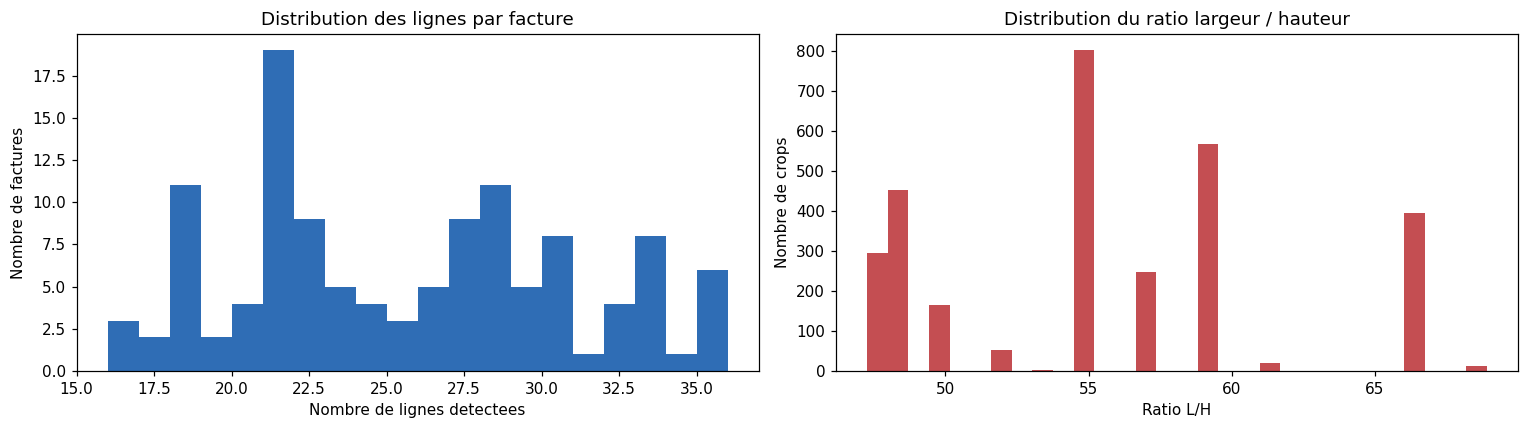

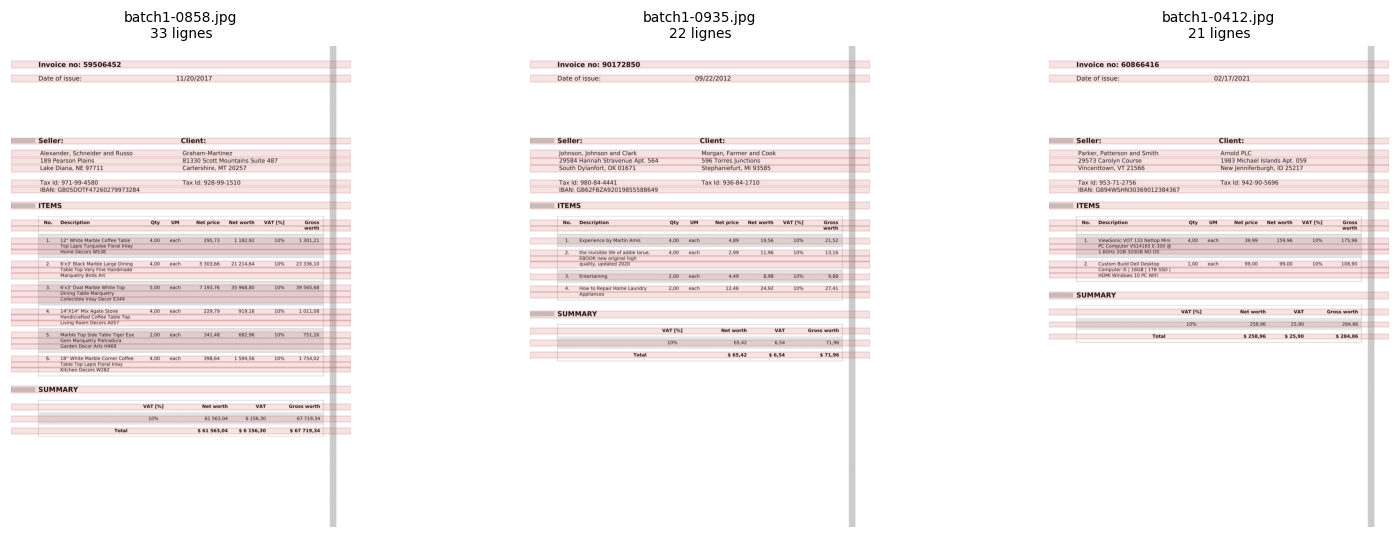

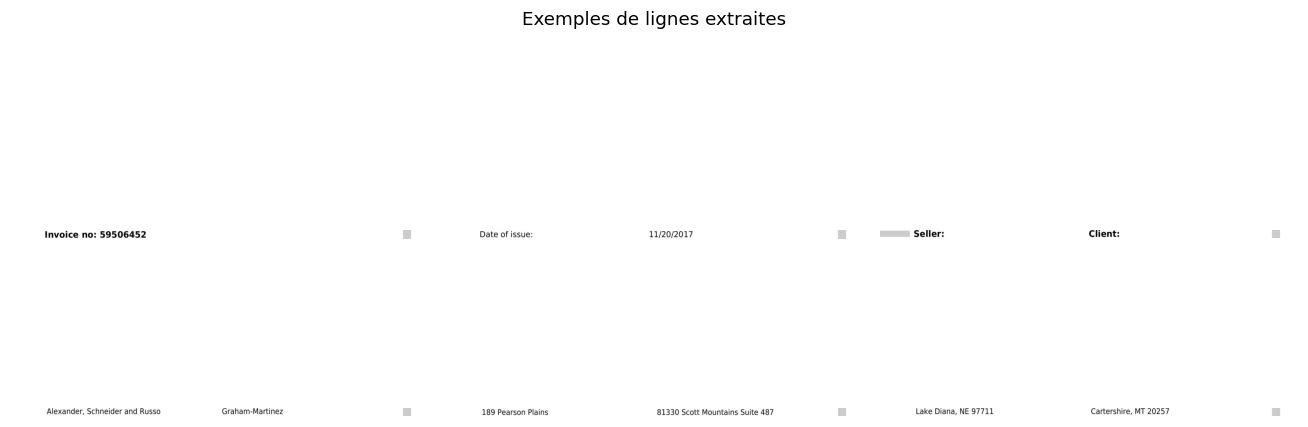

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_line_images["n_lines"], bins=20, color="#2F6DB5")
axes[0].set_title("Distribution des lignes par facture")
axes[0].set_xlabel("Nombre de lignes detectees")
axes[0].set_ylabel("Nombre de factures")

axes[1].hist(df_line_crops["aspect_ratio"], bins=30, color="#C44E52")
axes[1].set_title("Distribution du ratio largeur / hauteur")
axes[1].set_xlabel("Ratio L/H")
axes[1].set_ylabel("Nombre de crops")
plt.tight_layout()
plt.show()

if line_preview_pages:
    fig, axes = plt.subplots(1, len(line_preview_pages), figsize=(15, 5))
    if len(line_preview_pages) == 1:
        axes = [axes]
    for ax, preview in zip(axes, line_preview_pages):
        ax.imshow(preview["gray"], cmap="gray")
        for y0, y1, _ in preview["bounds"]:
            ax.axhspan(y0, y1, color="#C44E52", alpha=0.15)
        ax.set_title(f"{preview['filename']}\n{len(preview['bounds'])} lignes", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

if line_preview_crops:
    column_count = 3
    row_count = int(np.ceil(len(line_preview_crops) / column_count))
    fig, axes = plt.subplots(row_count, column_count, figsize=(12, 2.8 * row_count))
    axes = np.atleast_1d(axes).reshape(row_count, column_count)
    for ax, crop in zip(axes.flat, line_preview_crops):
        ax.imshow(np.array(crop))
        ax.axis("off")
    for ax in axes.flat[len(line_preview_crops):]:
        ax.axis("off")
    fig.suptitle("Exemples de lignes extraites", fontsize=12)
    plt.tight_layout()
    plt.show()


**Lecture :**
- Les bandes colorées superposées aux factures confirment que la projection horizontale isole les zones de texte et montrent ce que verra le modèle.
- La galerie de crops illustre le format réel des entrées soumises au modèle : des lignes fines et allongées qui imposent un traitement ligne par ligne dans la suite du pipeline.

## 9. Analyse layout / homogénéité des templates

Cette section reste volontairement qualitative. Le but n'est pas de construire une heatmap complexe, mais de vérifier rapidement si le dataset repose sur des layouts assez homogènes pour soutenir un pipeline regex sur quelques champs cibles.


#### Grille 3×3 de factures tirées aléatoirement

Analyse qualitative : les templates sont-ils suffisamment homogènes pour que des regex simples (`invoice_number`, `invoice_date`, `total`, `tax`) fonctionnent ?


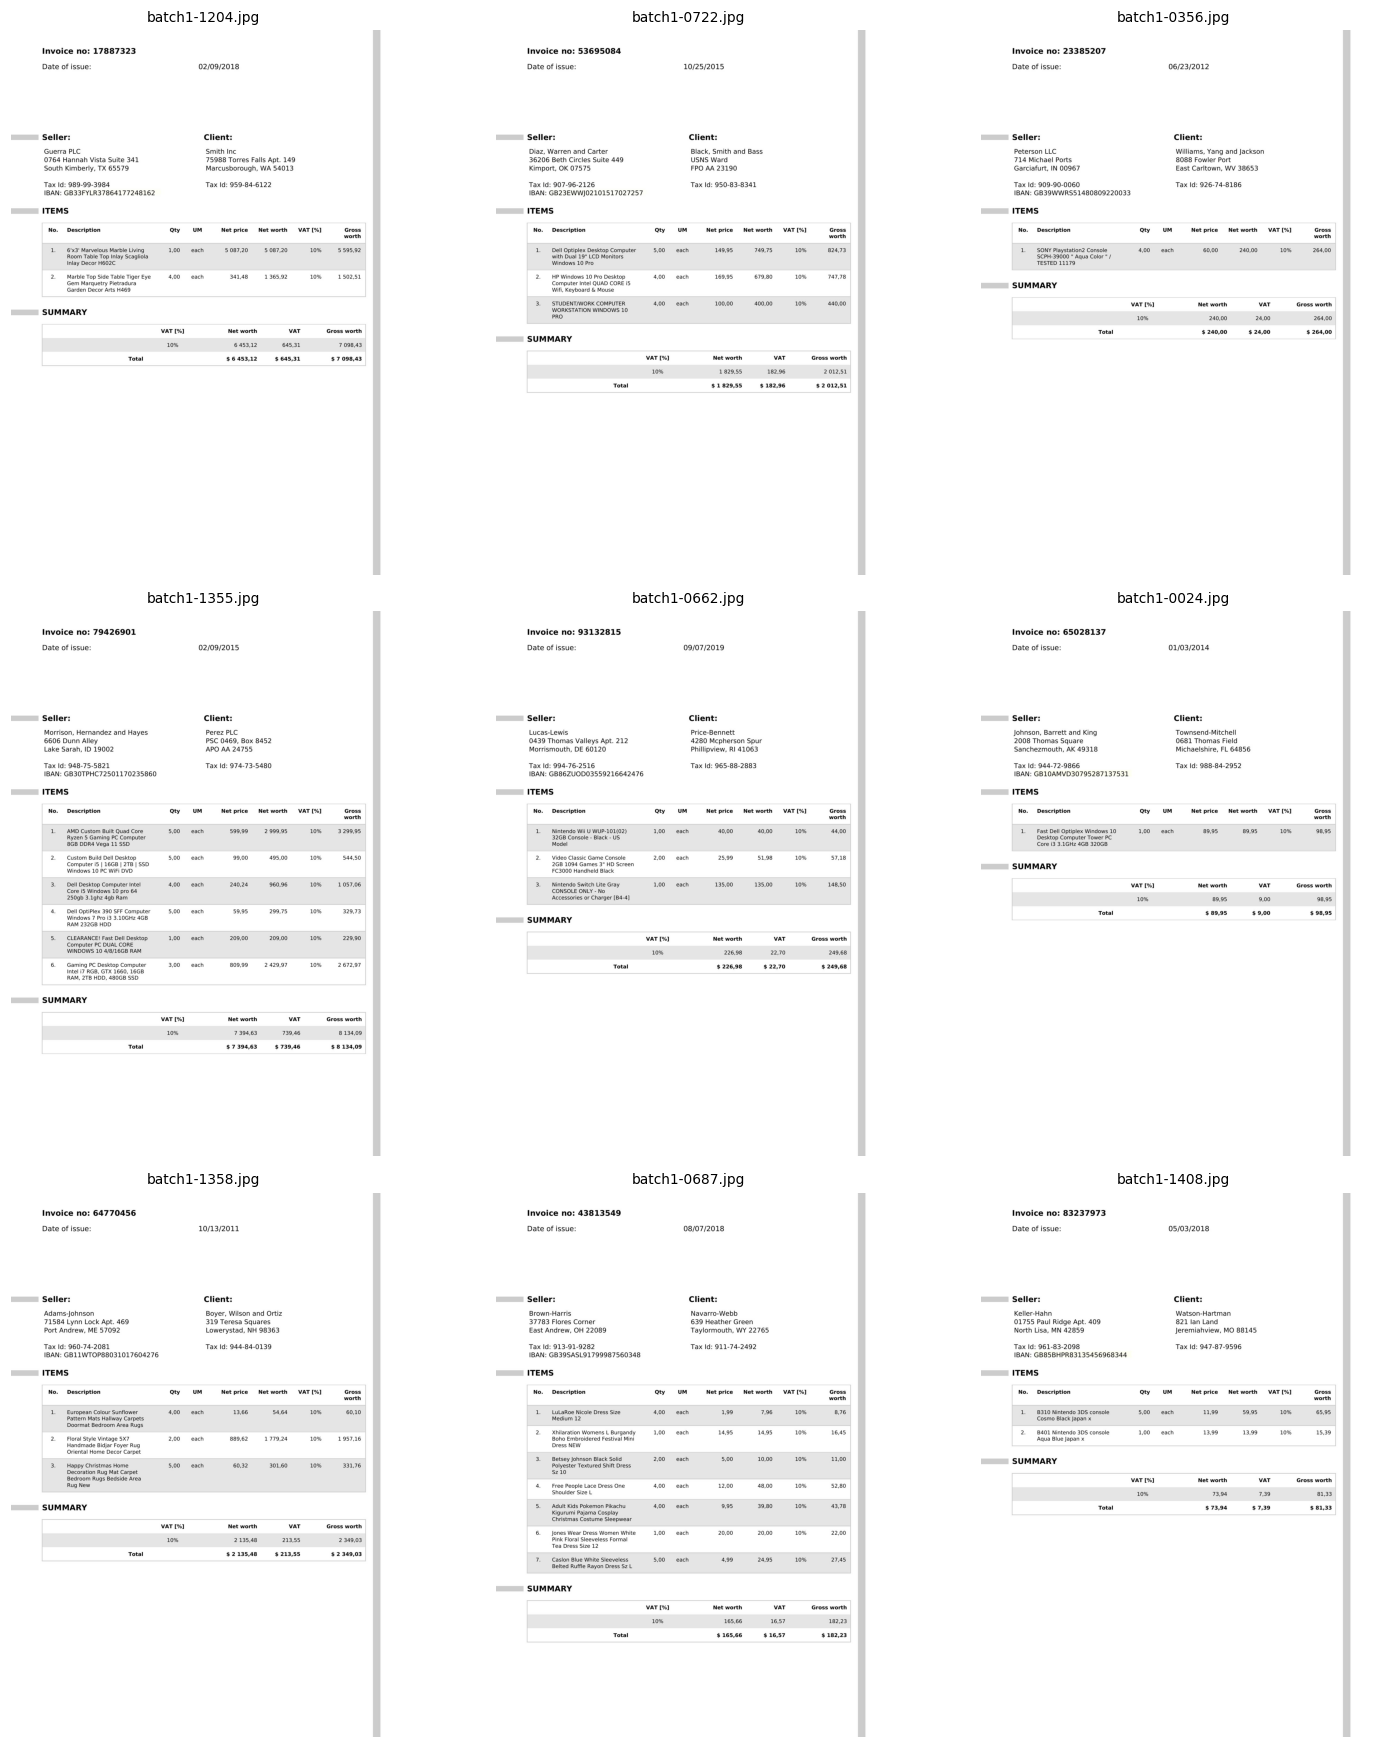

In [14]:
layout_paths = [find_invoice_image(name) for name in df_parsed.sample(min(9, len(df_parsed)), random_state=3)["filename"].tolist()]
layout_paths = [path for path in layout_paths if path is not None][:9]

fig, axes = plt.subplots(3, 3, figsize=(14, 16))
for ax, image_path in zip(axes.flat, layout_paths):
    image_rgb = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(image_rgb)
    ax.set_title(image_path.name, fontsize=9)
    ax.axis("off")
for ax in axes.flat[len(layout_paths):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


**Lecture qualitative du layout.**
- Les templates varient, mais les zones d'en-tête et de totaux apparaissent avec une régularité suffisante pour défendre un bloc regex sur `invoice_number`, `invoice_date`, `total` et `tax`.
- Par précaution, on considère que les zones de vendeur et d'adresse changent trop en longueur et en structure pour constituer de bonnes cibles regex dans un scope minimal.

## 10. Formats champs JSON + cohérence Json Data / OCRed Text


**Caractéristiques observées dans cette section**

- `invoice_date` : le format dominant observé dans le dataset est `MM/DD/YYYY`.
- `invoice_number` : identifiant de longueur fixe, majoritairement numérique.
- `total` et `tax` : valeurs numériques décimales présentes dans le JSON et dans le texte OCR.

**Note méthodologique**

Le test de concordance ci-dessous vérifie si la valeur normalisée du JSON apparaît comme sous-chaîne du texte OCR document. C'est un test d'alignement textuel strict et pas une mesure de la qualité OCR du modèle.

In [15]:
def classify_date_format(value):
    value = str(value).strip()
    if re.fullmatch(r"\d{2}/\d{2}/\d{4}", value):
        return "MM/DD/YYYY"
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", value):
        return "YYYY-MM-DD"
    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", value):
        return "DD-MM-YYYY"
    return "Autre"


def normalize_field_value(value):
    text = str(value).strip().lower()
    text = re.sub(r"\s+", "", text)
    text = text.replace("$", "")
    if "," in text and "." in text:
        text = text.replace(",", "")
    else:
        text = text.replace(",", ".")
    return text


def non_empty_series(series):
    cleaned = series.astype(str).str.strip()
    return cleaned[cleaned != ""]


def top_prefix_summary(values, prefix_length=2, limit=5):
    if values.empty:
        return "n/a"
    prefixes = values.str[:prefix_length].value_counts().head(limit)
    return ", ".join(f"{prefix} ({count})" for prefix, count in prefixes.items())


date_values = non_empty_series(df_parsed["inv_invoice_date"])
date_formats = Counter(date_values.map(classify_date_format))
date_format_rows = [
    {"format": format_name, "nombre": count}
    for format_name, count in sorted(date_formats.items(), key=lambda item: item[1], reverse=True)
]
df_date_formats = pd.DataFrame(date_format_rows)
df_date_formats["part_pct"] = (
    100 * df_date_formats["nombre"] / max(df_date_formats["nombre"].sum(), 1)
).round(1)

invoice_number_values = non_empty_series(df_parsed["inv_invoice_number"])
number_lengths = Counter(invoice_number_values.str.len())
dominant_length, dominant_length_count = number_lengths.most_common(1)[0]
dominant_length_share = 100 * dominant_length_count / max(sum(number_lengths.values()), 1)
numeric_rate = 100 * invoice_number_values.str.fullmatch(r"\d+").mean()
df_invoice_number_structure = pd.DataFrame(
    [
        {"indicateur": "Longueur dominante", "valeur": f"{dominant_length} caracteres"},
        {"indicateur": "Part de la longueur dominante", "valeur": f"{dominant_length_share:.1f}%"},
        {"indicateur": "Part entièrement numérique", "valeur": f"{numeric_rate:.1f}%"},
        {"indicateur": "Préfixes fréquents (2 caractères)", "valeur": top_prefix_summary(invoice_number_values)},
    ]
)

total_visible = 0
tax_visible = 0
rows_with_total = 0
rows_with_tax = 0
for _, row in df_parsed.iterrows():
    text_norm = normalize_field_value(row["ocr_text"])
    total_norm = normalize_field_value(row["sub_total"])
    tax_norm = normalize_field_value(row["sub_tax"])
    if total_norm:
        rows_with_total += 1
        total_visible += int(total_norm in text_norm)
    if tax_norm:
        rows_with_tax += 1
        tax_visible += int(tax_norm in text_norm)

df_visibility = pd.DataFrame(
    [
        {
            "champ": "total",
            "lignes_avec_valeur_json": rows_with_total,
            "valeurs_visibles_dans_ocr": total_visible,
            "visibilite_pct": round(100 * total_visible / max(rows_with_total, 1), 1),
        },
        {
            "champ": "tax",
            "lignes_avec_valeur_json": rows_with_tax,
            "valeurs_visibles_dans_ocr": tax_visible,
            "visibilite_pct": round(100 * tax_visible / max(rows_with_tax, 1), 1),
        },
    ]
)

print(f"Tables de référence construites ({len(df_date_formats)} formats de date détectés).")

Tables de référence construites (1 formats de date détectés).


Application structurée : on documente d'abord les formats observés, puis le proxy de visibilité JSON ↔ `OCRed Text`, puis le design regex qui sera repris dans le livrable final.


### Distribution des formats de date

In [16]:
display(df_date_formats)

,format,nombre,part_pct
0,MM/DD/YYYY,1414,100.0


### Structure observée des numéros de facture

In [17]:
display(df_invoice_number_structure)

,indicateur,valeur
0,Longueur dominante,8 caracteres
1,Part de la longueur dominante,100.0%
2,Part entièrement numérique,100.0%
3,Préfixes fréquents (2 caractères),"77 (27), 61 (25), 65 (24), 72 (23), 35 (23)"


### Cohérence textuelle JSON ↔ `OCRed Text` : test de concordance stricte

In [18]:
display(df_visibility)

date_dominant_format = df_date_formats.iloc[0]["format"]
date_dominant_share = df_date_formats.iloc[0]["part_pct"]
total_visibility = df_visibility.loc[df_visibility["champ"] == "total", "visibilite_pct"].iloc[0]
tax_visibility = df_visibility.loc[df_visibility["champ"] == "tax", "visibilite_pct"].iloc[0]



,champ,lignes_avec_valeur_json,valeurs_visibles_dans_ocr,visibilite_pct
0,total,1414,0,0.0
1,tax,1414,4,0.3


**Lecture.**
- `invoice_date` est observé dans un format dominant homogène, ce qui confirme l'uniformité du format date dans batch_1.
- `invoice_number` se comporte comme un identifiant purement numérique de longueur fixe.
- La visibilité normalisée de `total` et `tax` dans `OCRed Text` reste quasi nulle : c'est un **test de concordance textuelle stricte**, pas une mesure de la qualité OCR du modèle. `OCRed Text` est un texte plat document-level ; les correspondances ligne à ligne sont rares par construction.

## 11. Conclusion

### Ce que l'EDA confirme sur la donnée

- Le dataset batch_1 est structurellement propre : 0 image manquante, taux de remplissage élevé sur les champs principaux, résolutions homogènes.
- Les images sont déjà bien alignées et bien exposées ; le preprocessing jouera un rôle de normalisation, non de correction.
- La distribution des lignes de texte (médiane ~32px de hauteur, ratio L/H élevé) impose un traitement ligne par ligne, ce qui orientera la granularité d'entrée du modèle OCR retenu dans la suite du projet.
- Les biais identifiés bornent la portée supervisée : batch_1 reste le socle ; la généralisation à batch_2 et hors corpus constitue un test qualitatif, non une preuve supervisée au même niveau.

### Transition vers NB2 et NB3

NB2 prend en charge la normalisation des images (resize, CLAHE, deskew, denoise) et produit le module partagé `preprocessing.py`.

NB3 utilise batch_1 pour entraîner un modèle sur les crops de lignes extraits en s'appuyant sur ce même module.